# Heart Disease Prediction System

## Exploratory Data Analysis (EDA)

This notebook contains the exploratory data analysis, preprocessing, and model development for the Heart Disease Prediction System.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_excel("../dataset/Heart_Failure_Prediction_Dataset.xlsx",
                   sheet_name="Dataset",
                   header=3,
                   skiprows=0)


print("Dataset loaded successfully!")

c:\Users\FEMI\Desktop\HeartDiseasePrediction\venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\FEMI\Desktop\HeartDiseasePrediction\venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Dataset loaded successfully!


In [3]:
# Display the first five rows
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.shape

(918, 12)

In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [7]:
# Check for missing values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [9]:
# Statistical summary of numerical variables
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [10]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

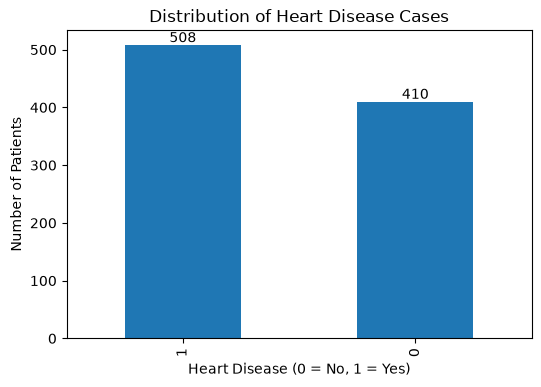

In [11]:
import matplotlib.pyplot as plt

# Count the target classes
heart_counts = df["HeartDisease"].value_counts()

# Create the figure
plt.figure(figsize=(6, 4))

# Plot the chart
heart_counts.plot(kind="bar")

# Add labels and title
plt.title("Distribution of Heart Disease Cases")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

# Add values on top of each bar
for index, value in enumerate(heart_counts):
    plt.text(index, value + 5, str(value), ha='center')

plt.show()

In [12]:
df["Sex"].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

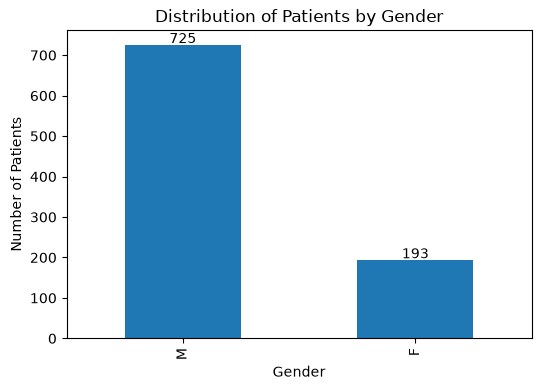

In [13]:
import matplotlib.pyplot as plt

sex_counts = df["Sex"].value_counts()

plt.figure(figsize=(6,4))

sex_counts.plot(kind="bar")

plt.title("Distribution of Patients by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

# Display values on top of bars
for index, value in enumerate(sex_counts):
    plt.text(index, value + 5, str(value), ha='center')

plt.show()

In [16]:
df["Age"].describe()

count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64

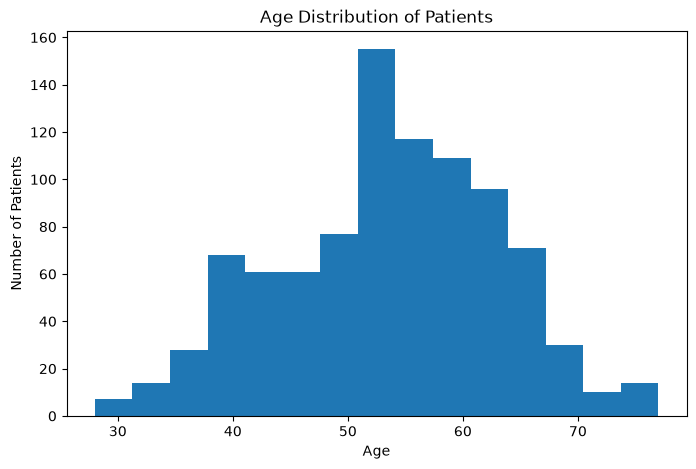

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=15)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()


In [17]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

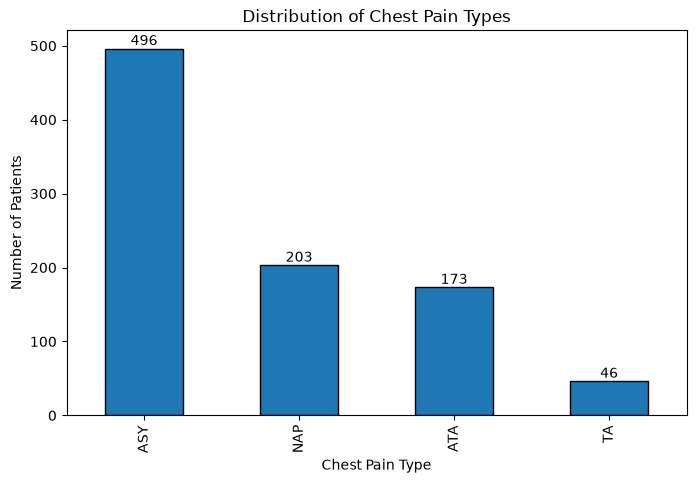

In [18]:
chest_counts = df["ChestPainType"].value_counts()

plt.figure(figsize=(8,5))

chest_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of Chest Pain Types")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

for index, value in enumerate(chest_counts):
    plt.text(index, value + 5, str(value), ha="center")

plt.show()

In [19]:
df["RestingBP"].describe()

count    918.000000
mean     132.396514
std       18.514154
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64

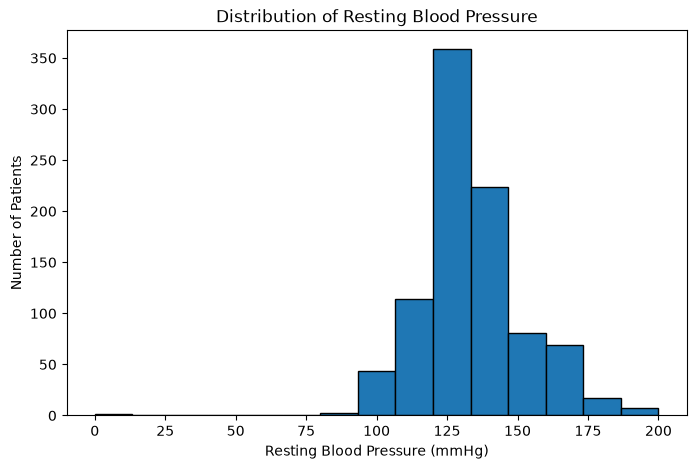

In [20]:
plt.figure(figsize=(8,5))

plt.hist(df["RestingBP"], bins=15, edgecolor="black")

plt.title("Distribution of Resting Blood Pressure")
plt.xlabel("Resting Blood Pressure (mmHg)")
plt.ylabel("Number of Patients")

plt.show()

C:\Users\FEMI\AppData\Local\Temp\ipykernel_16692\2352482158.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["RestingBP"], vert=False)


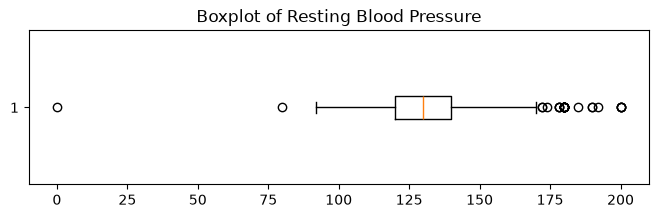

In [21]:
plt.figure(figsize=(8,2))

plt.boxplot(df["RestingBP"], vert=False)

plt.title("Boxplot of Resting Blood Pressure")

plt.show()

In [22]:
df["Cholesterol"].describe()

count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

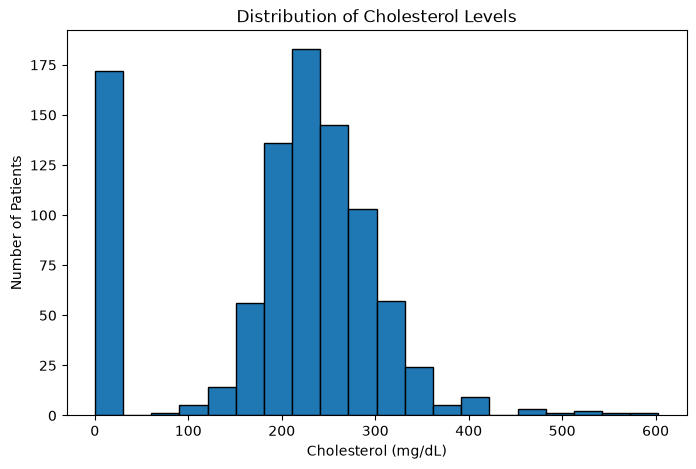

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["Cholesterol"], bins=20, edgecolor="black")

plt.title("Distribution of Cholesterol Levels")
plt.xlabel("Cholesterol (mg/dL)")
plt.ylabel("Number of Patients")

plt.show()

C:\Users\FEMI\AppData\Local\Temp\ipykernel_16692\62348449.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Cholesterol"], vert=False)


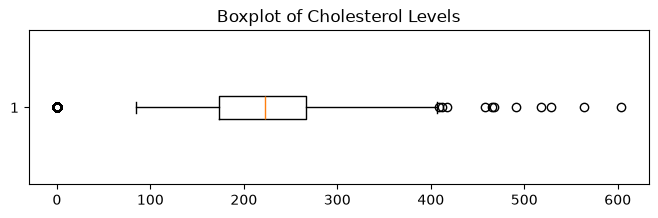

In [24]:
plt.figure(figsize=(8,2))

plt.boxplot(df["Cholesterol"], vert=False)

plt.title("Boxplot of Cholesterol Levels")

plt.show()

In [25]:
df["MaxHR"].describe()

count    918.000000
mean     136.809368
std       25.460334
min       60.000000
25%      120.000000
50%      138.000000
75%      156.000000
max      202.000000
Name: MaxHR, dtype: float64

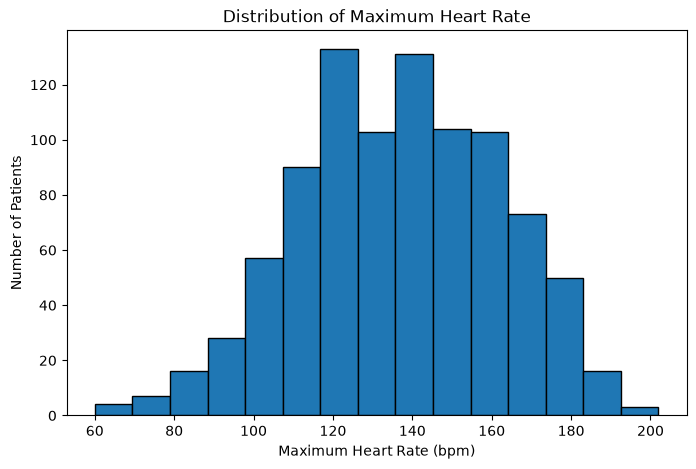

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df["MaxHR"], bins=15, edgecolor="black")

plt.title("Distribution of Maximum Heart Rate")
plt.xlabel("Maximum Heart Rate (bpm)")
plt.ylabel("Number of Patients")

plt.show()

C:\Users\FEMI\AppData\Local\Temp\ipykernel_16692\1018275559.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["MaxHR"], vert=False)


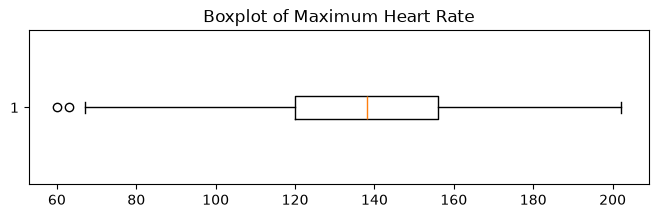

In [27]:
plt.figure(figsize=(8,2))

plt.boxplot(df["MaxHR"], vert=False)

plt.title("Boxplot of Maximum Heart Rate")

plt.show()

In [28]:
df["ExerciseAngina"].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

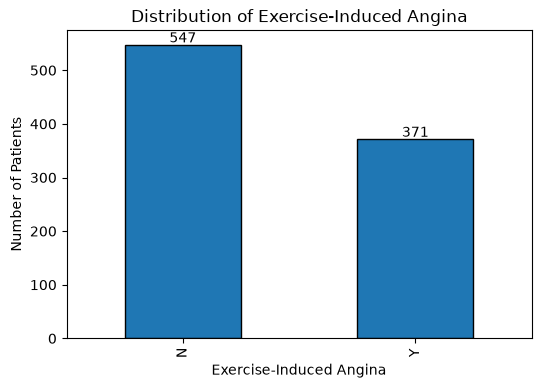

In [29]:
exercise_counts = df["ExerciseAngina"].value_counts()

plt.figure(figsize=(6,4))

exercise_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of Exercise-Induced Angina")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Number of Patients")

for index, value in enumerate(exercise_counts):
    plt.text(index, value + 5, str(value), ha="center")

plt.show()

In [30]:
df["RestingECG"].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

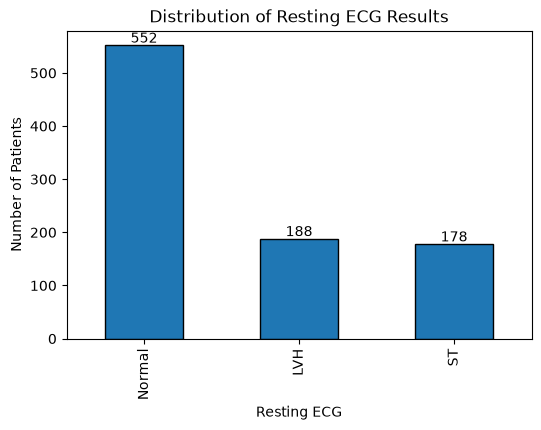

In [31]:
ecg_counts = df["RestingECG"].value_counts()

plt.figure(figsize=(6,4))

ecg_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of Resting ECG Results")
plt.xlabel("Resting ECG")
plt.ylabel("Number of Patients")

for index, value in enumerate(ecg_counts):
    plt.text(index, value + 5, str(value), ha="center")

plt.show()

In [32]:
df["FastingBS"].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

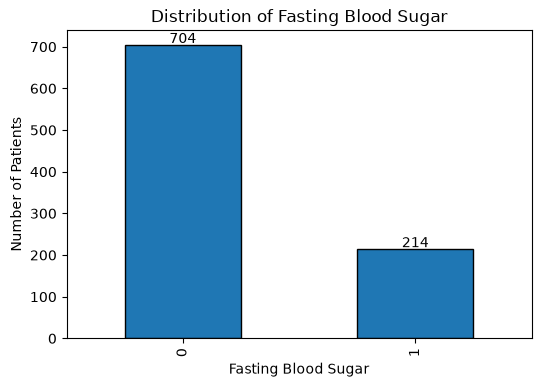

In [33]:
fasting_counts = df["FastingBS"].value_counts()

plt.figure(figsize=(6,4))

fasting_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of Fasting Blood Sugar")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Number of Patients")

for index, value in enumerate(fasting_counts):
    plt.text(index, value + 5, str(value), ha="center")

plt.show()

In [34]:
df["ST_Slope"].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

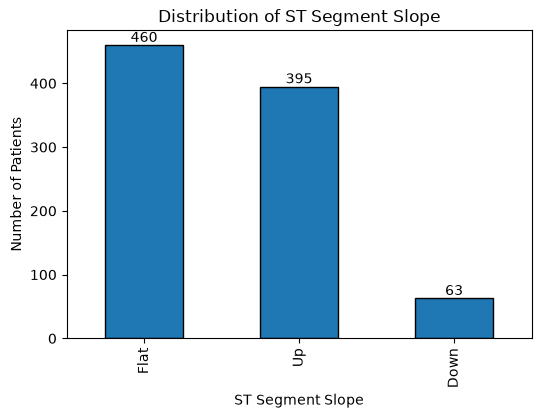

In [35]:
st_counts = df["ST_Slope"].value_counts()

plt.figure(figsize=(6,4))

st_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of ST Segment Slope")
plt.xlabel("ST Segment Slope")
plt.ylabel("Number of Patients")

for index, value in enumerate(st_counts):
    plt.text(index, value + 5, str(value), ha="center")

plt.show()